k=31: lap[-0.24727,0.00864] thr=0.1786 nonzero=391821
k=71: lap[-0.23180,0.00278] thr=0.1789 nonzero=391820
k=101: lap[-0.22892,0.00153] thr=0.1781 nonzero=391827


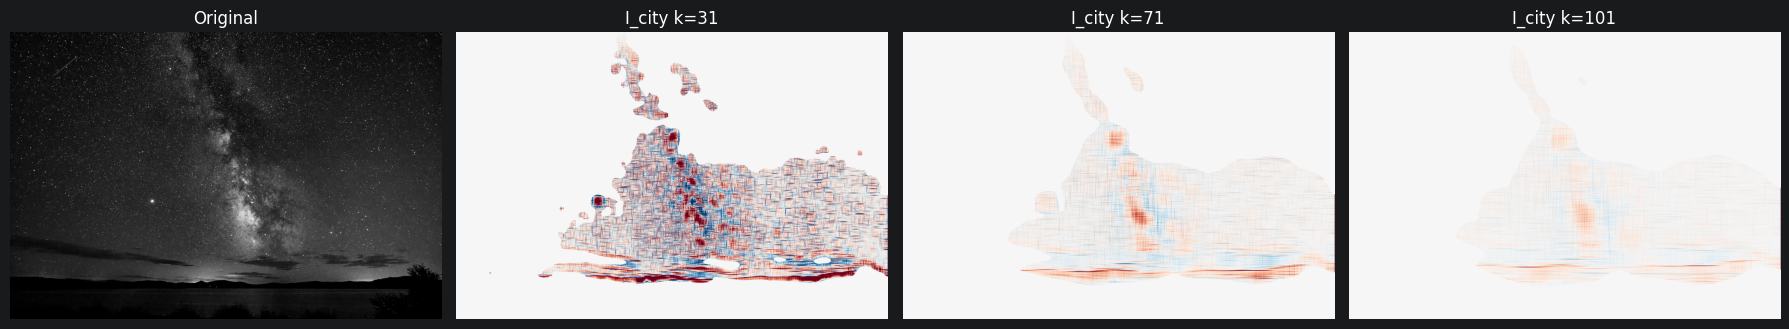

In [88]:
import torch
import numpy as np
import torch.nn.functional as F_conv

import pinn_starlight_core.data.PhotoLoader as Loader
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F

loader = Loader.RAWLoader()
loader.load(r"../../data/real_raw/origin/02.jpg")
gray = np.mean(loader.rgb_data, axis=2).astype(np.float32)
H, W = gray.shape
img1 = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0)   # (1, 1, H, W)

lap_kernel = torch.tensor([[0., 1., 0.], [1., -4., 1.], [0., 1., 0.]])
y = torch.linspace(0, 1, H, dtype=torch.float32)
decay = (1 - torch.exp(-y * 6)).unsqueeze(1)

I_cities = []
for ks in [31, 71, 101]:
    blur = F.gaussian_blur(img1, [ks, ks], sigma=[ks/3.0, ks/3.0]).squeeze()
    lap = F_conv.conv2d(blur.unsqueeze(0).unsqueeze(0), lap_kernel.view(1, 1, 3, 3), padding=1).squeeze()
    thr = blur.quantile(0.70)
    mask = blur > thr
    I_city = lap * mask.float() * decay
    I_cities.append(I_city)
    print(f"k={ks}: lap[{lap.min():.5f},{lap.max():.5f}] thr={thr:.4f} nonzero={(I_city!=0).sum().item()}")

# 显示 — 百分位裁剪去极端值
vmin = np.percentile(I_cities[0].abs().numpy(), 2)
vmax = np.percentile(I_cities[0].abs().numpy(), 98)
vlim = max(vmin, vmax)

fig, ax = plt.subplots(1, 4, figsize=(18, 4))
ax[0].imshow(gray, cmap='gray'); ax[0].set_title('Original')
for i, (ks, ic) in enumerate(zip([31, 71, 101], I_cities)):
    ax[i+1].imshow(ic, cmap='RdBu', vmin=-vlim, vmax=vlim)
    ax[i+1].set_title(f'I_city k={ks}')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()